# Estudo pontual: Ciclo Básico Unicamp → Terminal Barão Geraldo

Este notebook compara a distância intrínseca no grafo de ruas, denotada por

$$d_G(u,v),$$

com distâncias planas induzidas por normas $L^p$ entre as coordenadas projetadas dos mesmos vértices. Para cada métrica $d_p$, definimos a tortuosidade relativa

$$\tau_p(u,v)=\frac{d_G(u,v)}{d_p(u,v)}.$$

Assim, a tortuosidade não fica restrita à distância euclidiana: calculamos $\tau_1$, $\tau_2$, $\tau_{1.54}$, $\tau_\infty$ e assim por diante. O caso $p=2$ continua sendo a tortuosidade euclidiana usual, mas agora ele é apenas um caso particular.

## 1. Importações

Esta célula importa as bibliotecas gerais e o pacote `nao_e_so_reta`. O trecho que manipula `sys.path` permite rodar o notebook tanto a partir da pasta `notebooks/` quanto da raiz do projeto.

In [1]:
from pathlib import Path
import sys
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import nao_e_so_reta as sm

## 2. Configuração geral

Aqui definimos os pontos do estudo, os valores de $p$ que serão comparados, o tipo de rede e os caminhos para salvar dados e figuras. Os `fallbacks` são coordenadas manuais usadas caso o geocodificador não encontre o nome textual do local.

In [2]:
CFG = sm.AppConfig()

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
for folder in [DATA_DIR, RESULTS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

PLACE_CASE = CFG.place_case
NETWORK_TYPE = CFG.network_type
MAKE_UNDIRECTED = CFG.make_undirected

ORIGIN_QUERY = CFG.origin_query
DESTINATION_QUERY = CFG.destination_query
ORIGIN_FALLBACK_LATLON = CFG.origin_fallback_latlon
DESTINATION_FALLBACK_LATLON = CFG.destination_fallback_latlon

P_VALUES = sm.DEFAULT_P_VALUES

print("Valores de p:", [sm.p_value_label(p) for p in P_VALUES])

Valores de p: ['1', '1.25', '1.5', '1.54', '1.75', '2', '3', '5', '10', '∞']


## 3. Download ou carregamento do grafo

O grafo é baixado do OpenStreetMap via OSMnx ou carregado de um arquivo `.graphml` já salvo. Depois disso, ele é projetado para coordenadas métricas, convertido para grafo não direcionado e reduzido à maior componente conexa. Essa preparação garante que as distâncias $d_p$ estejam em metros e que os caminhos mínimos sejam bem definidos para a componente principal da rede.

In [3]:
# Aumenta a tolerância para consultas maiores ao Overpass.
import osmnx as ox
ox.settings.use_cache = True
ox.settings.log_console = False
ox.settings.requests_timeout = 600

graph_path = DATA_DIR / "graph_barao_geraldo.graphml"

try:
    G = sm.load_or_download_graph(
        graph_path,
        place=PLACE_CASE,
        network_type=NETWORK_TYPE,
        make_undirected=MAKE_UNDIRECTED,
        keep_largest_component=True,
    )
    print("Grafo carregado por nome de lugar.")
except Exception as exc:
    print("Falha ao carregar por nome de lugar:", repr(exc))
    print("Tentando recorte circular em torno de Barão Geraldo...")
    G = sm.load_or_download_graph(
        graph_path,
        place=None,
        center_point=CFG.barao_center,
        dist=CFG.barao_dist_m,
        network_type=NETWORK_TYPE,
        make_undirected=MAKE_UNDIRECTED,
        keep_largest_component=True,
    )

print(f"Vértices: {len(G.nodes):,}")
print(f"Arestas: {len(G.edges):,}")
print("CRS:", G.graph.get("crs"))

Grafo carregado por nome de lugar.
Vértices: 2,186
Arestas: 3,276
CRS: EPSG:32723


## 4. Estudo pontual

Agora transformamos os dois locais de interesse em vértices do grafo. O código geocodifica os nomes, encontra os nós mais próximos e calcula o menor caminho no grafo. Em seguida, calcula cada distância plana $d_p$ e cada tortuosidade relativa $	au_p=d_G/d_p$.

In [4]:
case_result, origin_point, destination_point = sm.compute_single_pair_from_queries(
    G,
    ORIGIN_QUERY,
    DESTINATION_QUERY,
    origin_fallback_latlon=ORIGIN_FALLBACK_LATLON,
    destination_fallback_latlon=DESTINATION_FALLBACK_LATLON,
    p_values=P_VALUES,
)

print("Origem usada (lat, lon):", origin_point)
print("Destino usado (lat, lon):", destination_point)
print("Nó de origem:", case_result.origin_node)
print("Nó de destino:", case_result.destination_node)
print(f"d_G = {case_result.graph_distance_m/1000:.3f} km")

C:\Users\caio24010\Documents\Gits\nao-e-so-reta\src\nao_e_so_reta\routing.py:171: RuntimeWarning: Falha ao geocodificar 'Ciclo Básico I - CB - Rua Monteiro Lobato, 421 - Cidade Universitária, Campinas - SP, Brazil'. Usando fallback_latlon=(-22.817132, -47.0682).
  warnings.warn(


Origem usada (lat, lon): (-22.817132, -47.0682)
Destino usado (lat, lon): (-22.8331509, -47.0799923)
Nó de origem: 1102485660
Nó de destino: 8239456512
d_G = 2.606 km


## 5. Gráfico do caminho

A figura abaixo mostra o menor caminho entre os dois vértices escolhidos. Esse caminho representa a distância intrínseca $d_G$ no grafo de ruas.

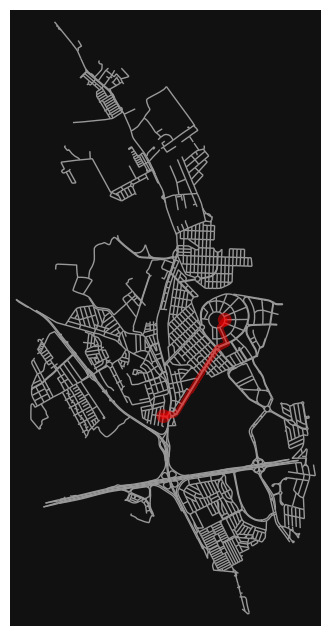

Figura salva em: C:\Users\caio24010\Documents\Gits\nao-e-so-reta\figures\rota_ciclo_basico_terminal.png


In [5]:
route_path = FIGURES_DIR / "rota_ciclo_basico_terminal.png"
fig, ax = sm.plot_route(G, case_result.route, filepath=route_path, show=False, close=False)
plt.show()
print("Figura salva em:", route_path)

## 6. Distâncias e tortuosidades por métrica

A tabela apresenta, para cada métrica plana $d_p$, a distância calculada, a tortuosidade relativa $	au_p=d_G/d_p$ e os erros em relação a $d_G$. Como a tabela é ordenada pelo erro absoluto, as primeiras linhas mostram as métricas que mais se aproximaram da distância intrínseca neste caso pontual.

In [6]:
case_table = sm.single_pair_table(case_result, sort_by_abs_error=True)
case_table_path = RESULTS_DIR / "caso_pontual_metricas.csv"
sm.save_dataframe(case_table, case_table_path)

case_table = case_table.drop(columns=["p", "d_G (km)"])

display(
    case_table.style.format({
        "τ_p = d_G/d_p": "{:.3f}",
        "Erro absoluto (m)": "{:.1f}",
        "Erro relativo (%)": "{:.2f}",
    })
)
print("Tabela salva em:", case_table_path)

,Métrica,d_p (km),τ_p = d_G/d_p,Erro absoluto (m),Erro relativo (%)
0,d_1.25,2.705786,0.963,99.7,3.82
1,d_1.5,2.481978,1.050,124.1,4.76
2,d_1.54,2.454729,1.062,151.4,5.81
3,d_1.75,2.337341,1.115,268.8,10.31
4,d_2,2.237483,1.165,368.6,14.14
5,d_1,3.088991,0.844,482.9,18.53
6,d_3,2.037572,1.279,568.5,21.82
7,d_5,1.925452,1.354,680.7,26.12
8,d_10,1.889617,1.379,716.5,27.49
9,d_∞,1.887567,1.381,718.5,27.57


Tabela salva em: C:\Users\caio24010\Documents\Gits\nao-e-so-reta\results\caso_pontual_metricas.csv


## 7. Leitura automática do melhor resultado pontual

Esta célula apenas extrai a primeira linha da tabela anterior para ajudar na discussão. No texto final, é importante lembrar que um único par origem-destino não é suficiente para concluir qual métrica é melhor em geral; ele funciona como estudo ilustrativo inicial.

In [7]:
best_case = case_table.iloc[0]
print(
    f"No caso pontual, a menor diferença absoluta ocorreu para {best_case['Métrica']}, "
    f"com erro de {best_case['Erro absoluto (m)']:.1f} m "
    f"e tortuosidade τ = {best_case['τ_p = d_G/d_p']:.3f}."
)

No caso pontual, a menor diferença absoluta ocorreu para d_1.25, com erro de 99.7 m e tortuosidade τ = 0.963.


## 8. Discussão

Este estudo pontual permite visualizar concretamente a diferença entre a distância intrínseca do grafo e as distâncias induzidas por normas. A razão

$$\tau_p=\frac{d_G}{d_p}$$

indica quanto a distância no grafo é maior ou menor que a distância plana usada como referência. Quando $\tau_p>1$, a distância no grafo é maior que $d_p$; quando $\tau_p<1$, a métrica plana considerada é maior que a distância no grafo.

Esse segundo caso pode ocorrer para métricas como $d_1$, já que a distância Manhattan pode superar o comprimento do caminho real se os eixos adotados não estiverem alinhados à orientação dominante da malha viária.

## 9. Conclusões do estudo pontual

O caso Ciclo Básico → Terminal Barão Geraldo serve como um primeiro teste de interpretação geométrica. Ele mostra que a comparação entre métricas depende não apenas da separação espacial entre os pontos, mas também da forma da malha urbana e da orientação dos eixos usados para calcular as normas $L^p$.

A próxima etapa é estatística: repetir a comparação para muitos pares de vértices, reduzindo a dependência de um único trajeto específico.